# ClearML Practical Learning - MLOps Sentinel

This notebook is used to practice ClearML step by step inside the Sentinel project.

## Learning roadmap
1. Tasks and experiment tracking
2. Parameters and configuration tracking
3. Scalars, plots, console logs, and artifacts
4. Dataset versioning
5. Model versioning
6. Re-running and cloning experiments
7. ClearML Serving architecture and deployment strategies


## Step 1 - Connect a notebook run to ClearML

Goal: create a ClearML Task and verify that the run appears in the ClearML UI.


In [1]:
from clearml import Task

# Create a new ClearML task for this notebook session
task = Task.init(
    project_name="Sentinel/ClearML-Learning",
    task_name="01-basic-task",
    task_type=Task.TaskTypes.training,
)

print("ClearML task created successfully")


ClearML Task: created new task id=35e5d6551192420ab859d619128c7ba8
ClearML results page: http://localhost:8080/projects/93886c631c714f928be6ba0c858418d7/experiments/35e5d6551192420ab859d619128c7ba8/output/log
2026-08-05 09:02:04,725 - clearml.resource_monitor - WARNING - Could not fetch GPU stats: NVML Shared Library Not Found
ClearML results page: http://localhost:8080/projects/93886c631c714f928be6ba0c858418d7/experiments/35e5d6551192420ab859d619128c7ba8/output/log
ClearML task created successfully


ClearML Monitor: GPU monitoring failed getting GPU reading, switching off GPU monitoring


### What to verify in the ClearML UI

- Project: `Sentinel/ClearML-Learning`
- Task: `01-basic-task`
- Status changes to Running while the cell is active
- Console output contains `ClearML task created successfully`


In [2]:
# Define experiment parameters
params = {
    "learning_rate": 0.001,
    "batch_size": 32,
    "epochs": 5,
    "optimizer": "Adam",
    "model_name": "MNISTClassifier",
}

# Connect parameters to ClearML
task.connect(params)

print(params)

{'learning_rate': 0.001, 'batch_size': 32, 'epochs': 5, 'optimizer': 'Adam', 'model_name': 'MNISTClassifier'}


In [3]:
# Get the ClearML logger for the current task
logger = task.get_logger()

for epoch in range(1, 6):
    train_loss = 1.0 / epoch
    val_loss = 1.2 / epoch
    train_acc = 0.70 + epoch * 0.05
    val_acc = 0.68 + epoch * 0.045

    logger.report_scalar(
        title="Loss",
        series="Train",
        value=train_loss,
        iteration=epoch,
    )

    logger.report_scalar(
        title="Loss",
        series="Validation",
        value=val_loss,
        iteration=epoch,
    )

    logger.report_scalar(
        title="Accuracy",
        series="Train",
        value=train_acc,
        iteration=epoch,
    )

    logger.report_scalar(
        title="Accuracy",
        series="Validation",
        value=val_acc,
        iteration=epoch,
    )

In [4]:
import json
from pathlib import Path

artifact_data = {
    "best_epoch": 5,
    "best_validation_accuracy": 0.905,
    "learning_rate": 0.001,
}

artifact_path = Path("experiment_summary.json")

artifact_path.write_text(
    json.dumps(artifact_data, indent=2),
    encoding="utf-8",
)

task.upload_artifact(
    name="experiment_summary",
    artifact_object=str(artifact_path),
)

True

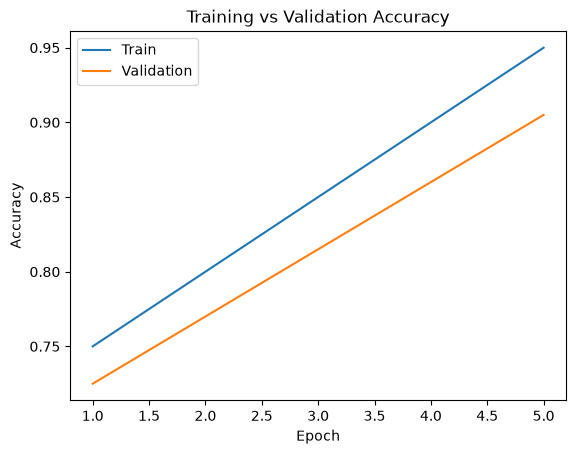

In [5]:
import matplotlib.pyplot as plt

epochs = [1, 2, 3, 4, 5]
train_accuracy = [0.75, 0.80, 0.85, 0.90, 0.95]
validation_accuracy = [0.725, 0.77, 0.815, 0.86, 0.905]

plt.figure()

plt.plot(
    epochs,
    train_accuracy,
    label="Train",
)

plt.plot(
    epochs,
    validation_accuracy,
    label="Validation",
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

logger.report_matplotlib_figure(
    title="Accuracy Comparison",
    series="Train vs Validation",
    figure=plt.gcf(),
)

plt.show()

In [6]:
from clearml import Dataset

dataset = Dataset.create(
    dataset_project="Sentinel",
    dataset_name="mnist",
    dataset_version="1.0.0",
)

print("Dataset created:", dataset.id)


ClearML results page: http://localhost:8080/projects/0d87df15a3ba4ac494e6b26c2fcf1688/experiments/e51dabd43782433783ee39a2323f9b65/output/log
ClearML dataset page: http://localhost:8080/datasets/simple/0d87df15a3ba4ac494e6b26c2fcf1688/experiments/e51dabd43782433783ee39a2323f9b65
Dataset created: e51dabd43782433783ee39a2323f9b65


In [7]:
from pathlib import Path

data_path = Path("../data/mnist.csv")

print("Exists:", data_path.exists())
print("Resolved path:", data_path.resolve())

Exists: True
Resolved path: /home/pulse80/Projects/sentinel/data/mnist.csv


In [8]:
dataset.add_files(
    path="../data/mnist.csv",
)

1

In [9]:
dataset.upload()
dataset.finalize()

print("Dataset uploaded and finalized successfully")

Uploading dataset changes (1 files compressed to 14.75 MiB) to http://localhost:8081
2026-08-05 09:02:28,485 - clearml.storage - INFO - Uploading: 5.00MB / 14.75MB @ 513.63MBs from /tmp/dataset.e51dabd43782433783ee39a2323f9b65.5ryh6_a9.zip
2026-08-05 09:02:28,493 - clearml.storage - INFO - Uploading: 10.00MB / 14.75MB @ 662.48MBs from /tmp/dataset.e51dabd43782433783ee39a2323f9b65.5ryh6_a9.zip
2026-08-05 09:02:28,506 - clearml.storage - INFO - Uploading: 14.75MB / 14.75MB @ 393.21MBs from /tmp/dataset.e51dabd43782433783ee39a2323f9b65.5ryh6_a9.zip
2026-08-05 09:02:28,507 - clearml.storage - INFO - Uploading: 14.75MB / 14.75MB @ 53.38MBs from /tmp/dataset.e51dabd43782433783ee39a2323f9b65.5ryh6_a9.zip
2026-08-05 09:02:28,508 - clearml.storage - INFO - Uploading: 14.75MB / 14.75MB @ 0.00MBs from /tmp/dataset.e51dabd43782433783ee39a2323f9b65.5ryh6_a9.zip
File compression and upload completed: total size 14.75 MiB, 1 chunk(s) stored (average size 14.75 MiB)
Dataset uploaded and finalized succ

In [10]:
from clearml import Dataset

dataset = Dataset.get(
    dataset_project="Sentinel",
    dataset_name="mnist",
    dataset_version="1.0.0",
)

print("Dataset ID:", dataset.id)

Dataset ID: e51dabd43782433783ee39a2323f9b65


In [11]:
dataset_path = dataset.get_local_copy()

print("Local dataset path:")
print(dataset_path)

Local dataset path:
/home/pulse80/.clearml/cache/storage_manager/datasets/ds_e51dabd43782433783ee39a2323f9b65


In [12]:
from pathlib import Path

dataset_root = Path(dataset.get_local_copy())
csv_path = dataset_root / "mnist.csv"

print("CSV path:", csv_path)
print("Exists:", csv_path.exists())

CSV path: /home/pulse80/.clearml/cache/storage_manager/datasets/ds_e51dabd43782433783ee39a2323f9b65/mnist.csv
Exists: True


In [13]:
import pandas as pd

df = pd.read_csv(csv_path)

print(df.shape)
df.head()

(70000, 785)


,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784,label
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,5
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,4
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,9


In [ ]:
from pathlib import Path
import torch

model_path = Path("demo_model.pt")

torch.save(
    {
        "model_name": "MNISTClassifier",
        "version": "1.0.0",
    },
    model_path,
)

print(model_path)

In [ ]:
# Close the task cleanly when the practice step is complete
task.close()
